# Pipeline MLP para Modelagem de OTFTs

Este notebook implementa um **pipeline completo** para modelagem de transistores orgânicos de filme fino (OTFTs) utilizando uma Rede Neural do tipo Perceptron Multicamadas (MLP).

O objetivo é treinar uma MLP capaz de prever a corrente de dreno $I_D$ a partir das tensões de operação, replicando o comportamento do modelo físico VSED (Virtual Source with Exponential Disorder) sem a necessidade de resolver as equações analíticas a cada inferência.

## Fluxo do pipeline

| Etapa | Seção | Descrição |
|-------|-------|-----------|
| 1 | Configuração | Definição de caminhos e variáveis globais |
| 2 | Bibliotecas | Importação dos módulos do projeto |
| 3 | Dados experimentais | Leitura dos CSVs de corrente × tensão |
| 4 | Modelo físico | Instância do TFTModel (VSED) |
| 5 | Dados sintéticos | Geração de curvas adicionais para treinamento |
| 6 | Treinamento MLP | Configuração e treinamento da rede neural |
| 7 | Avaliação | Comparação MLP vs. curva experimental real |
| 8 | [Avançado] Optuna | Busca automática de hiperparâmetros |

> **Pré-requisito:** ambiente Python configurado com `pip install -r requirements.txt`.  
> Execute as células **na ordem apresentada**.

---
## Seção 0 — Configuração de Caminhos De Arquivos

Esta é a **única célula que você precisa editar** antes de executar o notebook.

- `BASE_PATH`: caminho absoluto até a raiz do projeto `Model_OTFT/`
- `INDEX_PATH`: caminho para o arquivo `index_generated.json` produzido na Seção 5 (geração de dados sintéticos)
- `TECNOLOGY`: identificador textual da tecnologia orgânica analisada — usado para nomear os arquivos de modelo salvos

> **Dica:** No Windows, use barras duplas `\\` ou barras normais `/`. No Linux/Mac, use `/`.

In [1]:
# ============================================================
# EDITE APENAS ESTE BLOCO antes de executar o notebook
# ============================================================

# Caminho absoluto para a raiz do projeto
BASE_PATH = "/home/rsb6/Desktop/TCC/TCC implementation/Model_OTFT/"

# Identificador da tecnologia (usado para nomear o modelo salvo)
TECNOLOGY = "org1"

print("Configuração carregada com sucesso.")
print(f"  BASE_PATH       : {BASE_PATH}")
print(f"  TECNOLOGY       : {TECNOLOGY}")

Configuração carregada com sucesso.
  BASE_PATH       : /home/rsb6/Desktop/TCC/TCC implementation/Model_OTFT/
  TECNOLOGY       : org1


---
## Seção 1 — Carregar Bibliotecas

O projeto organiza toda a lógica em módulos dentro da pasta `modules_otft/`. Cada módulo tem responsabilidade específica:

| Módulo | Responsabilidade |
|--------|------------------|
| `_imports` | Dependências externas (numpy, pandas, matplotlib, etc.) |
| `_read_data` | Leitura e normalização dos arquivos CSV experimentais |
| `_model` | Implementação das equações físicas do OTFT (modelo VSED) |
| `_grafics` | Geração de gráficos das curvas I×V |
| `_menu` | Interface de seleção de arquivos (widgets interativos) |
| `_config` | Variáveis e constantes globais do projeto |
| `_utils` | Funções auxiliares compartilhadas entre as seções |
| `_display` | Formatação de saída no notebook |

Se esta célula gerar `ModuleNotFoundError`, certifique-se de que o kernel do Jupyter está apontando para o ambiente virtual correto e que você está executando o notebook a partir da raiz do projeto.

In [2]:
from modules_otft._imports import *
from modules_otft._read_data import ReadData
from modules_otft._model import TFTModel
from modules_otft._grafics import TFTGraphicsPlot
from modules_otft._menu import TFTMenu
from modules_otft._config import *
from modules_otft._utils import *
from modules_otft._display import display_settings

print("Todas as bibliotecas carregadas com sucesso.")

Todas as bibliotecas carregadas com sucesso.


---
## Seção 2 — Leitura dos Dados Experimentais

Os dados experimentais de um OTFT consistem em curvas de corrente × tensão medidas em laboratório:

- **Curva de transferência:** $V_{DS}$ fixo, $V_{GS}$ varia — revela o comportamento de chaveamento e a tensão de limiar ($V_{tho}$)
- **Curva de saída:** $V_{GS}$ fixo, $V_{DS}$ varia — revela as regiões linear e de saturação

Cada curva é armazenada em um arquivo CSV com três colunas obrigatórias: `VGS`, `VDS` e `ID`. O modelo identifica automaticamente o tipo de curva pela coluna com valor fixo.

Todas as configurações de leitura (caminhos, escalas de corrente, pré-processamento) são definidas no **arquivo JSON de configuração** selecionado abaixo. Consulte o `README.md` do projeto para a descrição completa de cada campo JSON.

### 2.1 — Criar objetos de leitura e selecionar arquivo de configuração

A célula abaixo instancia os objetos auxiliares e abre um **widget interativo** para você selecionar o arquivo JSON do experimento.

In [3]:
plot = TFTGraphicsPlot()
menu = TFTMenu()
read = ReadData()

In [4]:
# Abre um seletor interativo — escolha o arquivo JSON do seu experimento
settings = enter_with_json_file()

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


___________________________________________________________________________________ SETTINGS PRESENT IN THE JSON FILE:___________________________________________________________________________________

| path: /home/rsb6/Desktop/TCC/TCC implementation/Model_OTFT/datas/Org1/tipo p
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
| experimental_data_scale_transfer: A
---------------------------------------------------------------------------

### 2.2 — Carregar os arquivos CSV experimentais

Com o JSON carregado, esta etapa:
1. Determina as tensões fixas de cada curva (`get_load_voltages`)
2. Identifica o tipo de plot configurado — linear ou logarítmico (`get_type_plot`)
3. Calcula os deslocamentos de tensão (shift) a serem aplicados nas curvas de saída
4. Lê os arquivos CSV do diretório `path` especificado no JSON
5. Carrega os dados em arrays numpy: `Vv` (tensões), `Id` (correntes)

In [5]:
ld_voltages      = get_load_voltages(settings)
type_curve_plot  = get_type_plot(settings)
shift_list       = calculate_shift_list(settings)
list_tension_shift = get_shift_list(read, settings)

path_voltages = read.read_files_experimental(settings['path'], list_tension_shift)

Vv, Id, input_voltage, n_points, count_transfer, count_output = read.load_data(
    settings['type_read_data_exp'],
    path_voltages,
    settings['current_typic'],
    settings['experimental_data_scale_transfer'],
    settings['experimental_data_scale_output'],
    type_curve_plot
)

print(f"Curvas de transferência carregadas : {count_transfer}")
print(f"Curvas de saída carregadas         : {count_output}")
print(f"Pontos por curva                   : {n_points}")

[ReadData] Curvas com comprimentos diferentes foram reamostradas em toda a faixa do eixo. Prefira 'read interpolated data' ao comparar dados tratados por histerese.
Curvas de transferência carregadas : 2
Curvas de saída carregadas         : 3
Pontos por curva                   : 50


### 2.3 — Aplicar shift local nas curvas de saída

O **shift local** corrige pequenos desalinhamentos de tensão nas curvas de saída. Esses desalinhamentos surgem de resistências parasitas em série (resistência de contato) que fazem com que a tensão efetiva no canal seja menor que a tensão aplicada externamente.

O campo `apply_local_output_shift` no JSON habilita ou desabilita esta correção. Se estiver como `"yes"`, os valores em `output_shift_volt_data` são subtraídos das tensões de cada curva de saída correspondente.

> **Nota:** Se o shift não estiver ativado no JSON, esta célula não altera os dados — execute-a mesmo assim para manter as variáveis consistentes.

In [6]:
path_voltages, new_values_tension, new_list_tension = filter_and_load_files(
    read, settings, path_voltages, list_tension_shift
)

Vv, Id, input_voltage, n_points, count_transfer, count_output = read.load_data(
    settings['type_read_data_exp'],
    path_voltages,
    settings['current_typic'],
    settings['experimental_data_scale_transfer'],
    settings['experimental_data_scale_output'],
    type_curve_plot
)

list_tension_shift = new_values_tension
list_tension       = new_list_tension

print("Shift aplicado. Dados prontos para modelagem.")

[ReadData] Curvas com comprimentos diferentes foram reamostradas em toda a faixa do eixo. Prefira 'read interpolated data' ao comparar dados tratados por histerese.
Shift aplicado. Dados prontos para modelagem.


---
## Seção 3 — Instanciar o Modelo Físico (TFTModel)

O `TFTModel` implementa as equações do modelo **VSED** (Virtual Source with Exponential Disorder), um modelo compacto para OTFTs que descreve a corrente de dreno por:

$$J_D = V_{sat} \cdot F_{sat} \cdot Q_{free}$$

onde $Q_{free}$ é a densidade de cargas livres modulada pela tensão de gate, $V_{sat}$ é a velocidade de saturação dos portadores e $F_{sat}$ é um fator de transição linear→saturação.

Os **7 parâmetros físicos** do modelo ($V_{tho}$, $\delta$, $n$, $l$, $\lambda$, $V_{crit}$, $J_{th}$) foram previamente extraídos por ajuste numérico no notebook `TFT_M1_LAMB_MC.ipynb` e armazenados no campo `loaded_parameters` do arquivo JSON.

Aqui instanciamos o modelo com as tensões e o número de pontos lidos na seção anterior — ele será usado na próxima seção para gerar dados sintéticos.

In [7]:
Model = TFTModel(list_tension, n_points)

print(f"TFTModel instanciado.")
print(f"  Tensões de operação : {list_tension}")
print(f"  Pontos por curva    : {n_points}")

TFTModel instanciado.
  Tensões de operação : [-50.0, -2.0, -48.02582824633106, -39.281501478403705, -30.635024698945415]
  Pontos por curva    : 50


---
## Seção 4 — Geração de Dados Sintéticos

### Por que gerar dados sintéticos?

Uma MLP precisa de **volume de dados** para generalizar. Experimentos com OTFTs tipicamente produzem dezenas de curvas por dispositivo — insuficiente para treinar uma rede neural robusta. A solução é usar o modelo físico VSED para **extrapolar** novas curvas I×V com tensões diferentes das medidas, mantendo os parâmetros físicos constantes.

O processo é válido porque os parâmetros físicos ($V_{tho}$, $l$, $n$, etc.) caracterizam o **material** do dispositivo, não dependem das tensões aplicadas. Portanto, curvas geradas com tensões variadas representam medições que poderiam ter sido feitas no mesmo transistor.

### Como funciona o `SyntheticFromSettings`

1. Lê os parâmetros de `loaded_parameters` no JSON
2. Para cada curva experimental encontrada, gera variações com tensões incrementadas/decrementadas
3. Calcula $I_D$ pelo modelo VSED para cada nova tensão
4. Salva os CSVs sintéticos com o mesmo formato dos experimentais (`VGS`, `VDS`, `ID`)
5. Gera um arquivo `index_generated.json` listando todos os CSVs produzidos

**Parâmetros de geração:**
- `resample_n_points`: pontos por curva sintética (10000 dá alta resolução)
- `variation_mode="voltages"`: varia as tensões mantendo os parâmetros físicos fixos
- `voltage_increment`: passo de variação (V) — menor = mais variações intermediárias
- `voltage_max_variation`: variação máxima a partir da tensão original (V)

In [8]:
from modules_otft._generate_synthetic_data import SyntheticFromSettings

gen = SyntheticFromSettings(
    settings,
    model_cls=TFTModel,
    out_root="synthetic_from_settings"
)

print("Gerador de dados sintéticos instanciado.")
print("Execute a próxima célula para iniciar a geração.")

Gerador de dados sintéticos instanciado.
Execute a próxima célula para iniciar a geração.


In [9]:
# # A geração pode levar alguns minutos dependendo de resample_n_points e do número de curvas
# generated_index = gen.generate(
#     resample_n_points=10000,
#     variation_mode="voltages",
#     voltage_increment=2.0,
#     voltage_max_variation=30
# )

# print(f"\nGeração concluída.")
# print(f"Índice dos arquivos gerados salvo em: {generated_index}")
# print("Atualize INDEX_PATH na Seção 0 se quiser usar esses dados no treinamento.")

In [10]:
# ============================================================
# EDITE APENAS ESTE BLOCO antes de executar as proximas seções
# ============================================================

# Caminho para o índice JSON dos dados sintéticos (gerado na Seção 5)
INDEX_PATH = BASE_PATH + "datas/Org1/tipo p/index_exp_datas.json"

print("Configuração carregada com sucesso.")
print(f"  BASE_PATH       : {BASE_PATH}")
print(f"  INDEX_PATH      : {INDEX_PATH}")


Configuração carregada com sucesso.
  BASE_PATH       : /home/rsb6/Desktop/TCC/TCC implementation/Model_OTFT/
  INDEX_PATH      : /home/rsb6/Desktop/TCC/TCC implementation/Model_OTFT/datas/Org1/tipo p/index_exp_datas.json


---
## Seção 5 — Treinamento do Modelo MLP

### O que a MLP aprende?

A rede neural é treinada para aprender a função:

$$\ln|I_D| = f(V_{GS},\; V_{DS},\; V_{GS,fixo},\; V_{DS,fixo},\; \text{tipo})$$

onde:
- $V_{GS}$, $V_{DS}$: tensões varridas na curva
- $V_{GS,fixo}$ ou $V_{DS,fixo}$: tensão mantida constante durante a medição
- `tipo`: indica se é curva de transferência (0) ou de saída (1)

A saída é $\ln|I_D|$ (logaritmo natural da corrente) em vez de $I_D$ diretamente. Isso é necessário porque a corrente varia em várias ordens de magnitude — trabalhar em escala log estabiliza o gradiente e melhora a convergência.

### Hiperparâmetros

| Parâmetro | Descrição | Valor padrão |
|-----------|-----------|-------------|
| `HIDDEN_LAYERS` | Neurônios por camada oculta, ex: `(3, 3, 3)` = 3 camadas com 3 neurônios cada | `(3, 3, 3)` |
| `EPOCS` | Número máximo de épocas de treinamento | `10000` |
| `LEARNING_RATE` | Taxa de aprendizado do otimizador Adam | `~0.0003` |
| `BATSIZE` | Tamanho do mini-batch (amostras por atualização de pesos) | `64` |
| `PATIENCE` | Épocas sem melhora antes de parar (early stopping) | `1000` |
| `TEST_SPLIT` | Fração dos dados reservada para validação | `0.2` |

> **Sugestão:** use os valores padrão para uma primeira execução. Se os resultados na Seção 6 não forem satisfatórios, execute a Seção 8 (Optuna) para encontrar melhores hiperparâmetros automaticamente.

### 5.1 — Importar o módulo de treinamento

In [11]:
from modules_otft._mlp_train import MLPModelTrain

### 5.2 — Definir hiperparâmetros e instanciar o treinador

In [12]:
# Hiperparâmetros — ajuste conforme os resultados do Optuna (Seção 8) se necessário
HIDDEN_LAYERS = (3, 3, 3)
EPOCS         = 10000
TEST_SPLIT    = 0.2
LEARNING_RATE = 0.0002931453661651854
BATSIZE       = 64
PATIENCE      = 2000

mlp_trainer = MLPModelTrain(
    index_path=INDEX_PATH,
    hidden_layers=HIDDEN_LAYERS,
    activation='tanh',
    learning_rate=LEARNING_RATE,
    max_iter=EPOCS,
    batch_size=BATSIZE,
    n_iter=PATIENCE,
    test_size=TEST_SPLIT,
    model_path=f'models/mlp_model_{TECNOLOGY}.pkl',
)

print(f"Treinador instanciado com sucesso.")
print(f"Arquitetura: Input (5 features) → {HIDDEN_LAYERS} → Output (ln|Id|)")

Treinador instanciado com sucesso.
Arquitetura: Input (5 features) → (3, 3, 3) → Output (ln|Id|)


### 5.3 — Treinar o modelo

O treinamento usa o algoritmo **Adam** com *early stopping*: se o erro de validação não melhorar por `PATIENCE` épocas consecutivas, o treinamento é interrompido automaticamente e o melhor conjunto de pesos é restaurado.

O modelo treinado é salvo automaticamente no caminho definido em `model_path`.

In [13]:
# # O treinamento pode levar alguns minutos dependendo dos hiperparâmetros e do volume de dados
# val_mse = mlp_trainer.train_model()

# print(f"\nTreinamento concluído.")
# print(f"MSE de validação final: {val_mse:.6e}")

---
## Seção 6 — Avaliação: Comparação MLP vs. Curva Real

### Como interpretar os gráficos

Após o treinamento, comparamos a previsão da MLP com uma curva experimental real. A avaliação é feita em dois tipos de escala:

- **Escala logarítmica:** revela a precisão na **região subthreshold** (correntes muito baixas, próximas ao limiar de condução). Desvios nessa região indicam que a MLP não aprendeu corretamente a inclinação subthreshold (parâmetro $n/l$).
- **Escala linear:** revela a precisão na **região de saturação** (correntes altas). Desvios aqui indicam problemas no ajuste da corrente máxima ($J_{th}$).

O arquivo `infer_curve.json` especifica qual curva real usar para a comparação (configurado na Seção 0).

### 6.1 — Carregar modelo treinado e dados de inferência

In [23]:
# Caminho para o JSON de inferência (curva real usada na avaliação — Seção 7)
INFER_JSON_PATH = BASE_PATH + "models/infer_curve.json"

# Caminho para o modelo pré-treinado a ser carregado na avaliação
# Altere para o caminho do modelo que você treinou ou baixou
TRAINED_MODEL_PATH = BASE_PATH + "models/real_datas/mlp_model_org1.pkl"


print(f"  INFER_JSON_PATH : {INFER_JSON_PATH}")
print(f"  TRAINED_MODEL   : {TRAINED_MODEL_PATH}")

  INFER_JSON_PATH : /home/rsb6/Desktop/TCC/TCC implementation/Model_OTFT/models/infer_curve.json
  TRAINED_MODEL   : /home/rsb6/Desktop/TCC/TCC implementation/Model_OTFT/models/real_datas/mlp_model_org1.pkl


In [24]:
from modules_otft._inferency import plot_curve_comparison, prepare_mlp_features, load_data_for_inference
import numpy as np

trained_model, feature_scaler, target_scaler = mlp_trainer.load_model(
    filename=TRAINED_MODEL_PATH
)

V_real, I_real, v_fixed, is_transfer = load_data_for_inference(INFER_JSON_PATH)

tipo_curva = "transferência" if is_transfer else "saída"
print(f"Modelo carregado: {TRAINED_MODEL_PATH}")
print(f"Curva de avaliação: {tipo_curva} | V_fixo = {v_fixed} V | {len(V_real)} pontos")

Modelo carregado: /home/rsb6/Desktop/TCC/TCC implementation/Model_OTFT/models/real_datas/mlp_model_org1.pkl
Curva de avaliação: transferência | V_fixo = -44.0 V | 10000 pontos


### 6.2 — Gráfico em escala logarítmica

Use esta visualização para avaliar a qualidade do ajuste na região subthreshold e verificar se a inclinação da curva está correta.

In [25]:
plot_curve_comparison(
    V_data=V_real,
    I_real=I_real,
    V_fixed=v_fixed,
    is_transfer=is_transfer,
    mlp_model=(prepare_mlp_features, trained_model, feature_scaler, target_scaler),
    yscale="log",
    title="Previsão MLP vs. Curva Real — Escala Logarítmaica"
)

### 6.3 — Gráfico em escala linear

Use esta visualização para avaliar a precisão na região de saturação e verificar o nível absoluto de corrente previsto.

In [42]:
plot_curve_comparison(
    V_data=V_real,
    I_real=I_real,
    V_fixed=v_fixed,
    is_transfer=is_transfer,
    mlp_model=(prepare_mlp_features, trained_model, feature_scaler, target_scaler),
    yscale="linear",
    title="Previsão MLP vs. Curva Real — Escala Linear"
)

---
## Seção 7 — Curva de Aprendizado

A curva de aprendizado mostra como o erro (loss) do modelo evoluiu ao longo das épocas de treinamento.

**Como interpretar:**
- Curva que decresce suavemente e estabiliza → treinamento bem-sucedido
- Curva que oscila muito → taxa de aprendizado alta demais (reduza `LEARNING_RATE`)
- Curva que não converge após muitas épocas → arquitetura insuficiente (aumente `HIDDEN_LAYERS`) ou dados insuficientes
- Curva que para cedo com erro alto → `PATIENCE` muito baixo ou `EPOCS` insuficiente

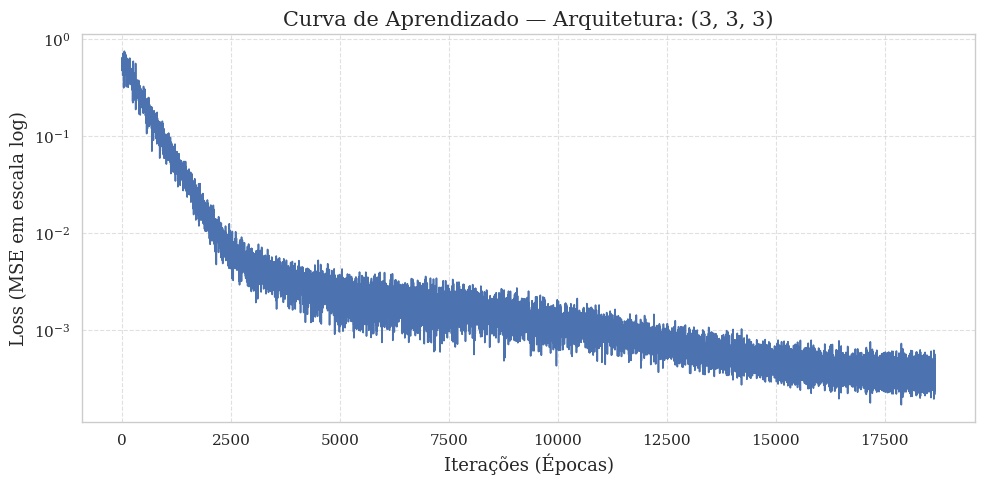

In [18]:
import matplotlib.pyplot as plt

def plot_learning_curve(trainer):
    plt.figure(figsize=(10, 5))
    plt.plot(trainer.model.loss_curve_)
    plt.title(f'Curva de Aprendizado — Arquitetura: {trainer.hidden_layers}')
    plt.xlabel('Iterações (Épocas)')
    plt.ylabel('Loss (MSE em escala log)')
    plt.yscale('log')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

plot_learning_curve(mlp_trainer)

---
## Seção 8 — \[AVANÇADO\] Busca Automática de Hiperparâmetros com Optuna

> **Esta seção é opcional.** Execute-a apenas quando quiser otimizar sistematicamente a arquitetura da MLP. O processo executa múltiplos treinamentos e pode levar **10 a 30 minutos**.

### O que é busca de hiperparâmetros?

Os hiperparâmetros (número de camadas, neurônios, taxa de aprendizado, etc.) não são aprendidos pelo modelo — precisam ser definidos antes do treinamento. Escolher os valores manualmente é trabalhoso e pouco sistemático.

O **Optuna** automatiza essa busca com um algoritmo de otimização Bayesiana: a cada *trial*, ele propõe uma combinação de hiperparâmetros, treina o modelo e mede o erro de validação. Ao longo dos trials, aprende quais regiões do espaço de busca prometem melhores resultados.

### Estratégia adotada: busca minimalista

Para datasets pequenos como os de OTFT, redes com **poucos neurônios** tendem a generalizar melhor do que redes profundas. O espaço de busca está propositalmente limitado (1–3 camadas, 1–5 neurônios por camada) para evitar overfitting.

Uma penalidade leve por complexidade (`0.0001 × soma dos neurônios`) faz o Optuna preferir arquiteturas mais simples quando o ganho de precisão é marginal.

### Como usar os resultados

Após a otimização, copie os valores impressos em `study.best_params` para a célula de hiperparâmetros da **Seção 5** e re-execute o treinamento completo.

### 8.1 — Configuração

In [19]:
import optuna
import warnings

warnings.filterwarnings('ignore')

print("Optuna carregado. Execute as próximas células para iniciar a busca.")

Optuna carregado. Execute as próximas células para iniciar a busca.


### 8.2 — Definir a função objetivo

A função objetivo é chamada pelo Optuna a cada trial. Ela recebe as sugestões de hiperparâmetros, treina o modelo e retorna o erro de validação (MSE). O Optuna tenta minimizar esse valor.

In [20]:
def objective(trial):
    # Espaço de busca: arquiteturas simples para evitar overfitting em datasets pequenos
    n_layers     = trial.suggest_int('n_layers', 1, 3)
    hidden_layers = tuple(
        trial.suggest_int(f'n_units_layer_{i}', 1, 5) for i in range(n_layers)
    )
    activation    = trial.suggest_categorical('activation', ['relu', 'tanh', 'silu'])
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    batch_size    = trial.suggest_categorical('batch_size', [16, 32, 64])

    print(f"\n--- Trial {trial.number} | Camadas: {hidden_layers} | {activation} | LR: {learning_rate:.5f} ---")

    trainer = MLPModelTrain(
        index_path=INDEX_PATH,
        hidden_layers=hidden_layers,
        activation=activation,
        learning_rate=learning_rate,
        max_iter=5000,
        batch_size=batch_size,
        n_iter=150,
        test_size=0.2,
        model_path=f'models/optuna_trials/mlp_model_{TECNOLOGY}_trial_{trial.number}.pkl'
    )

    try:
        val_mse = trainer.train_model()
        # Penalidade leve por complexidade: prefere redes menores se o ganho for marginal
        return val_mse + (0.0001 * sum(hidden_layers))
    except Exception as e:
        print(f"Erro no trial {trial.number}: {e}")
        raise optuna.exceptions.TrialPruned()

### 8.3 — Executar a busca (30 trials)

In [ ]:
study = optuna.create_study(
    direction="minimize",
    study_name="Otimizacao_MLP_OTFT"
)

print("Iniciando busca de hiperparâmetros (30 trials)...")
study.optimize(objective, n_trials=30)

print("\n" + "="*60)
print(f"Melhor MSE de Validação : {study.best_value:.6e}")
print("Melhores Hiperparâmetros:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")
print("="*60)
print("\nCopie os valores acima para a célula de hiperparâmetros da Seção 5 e re-execute o treinamento.")

[I 2026-06-08 15:54:19,236] A new study created in memory with name: Otimizacao_MLP_OTFT


Iniciando busca de hiperparâmetros (30 trials)...

--- Trial 0 | Camadas: (2, 2) | relu | LR: 0.00014 ---
Carregando índice de dados em: /home/rsb6/Desktop/TCC/TCC implementation/Model_OTFT/datas/Org1/tipo p/index_exp_datas.json
Padronizando Features (X) e Target (Y)...
Iniciando treinamento customizado da MLP (Scikit-Learn)...
Arquitetura: Input(5) -> (2, 2) -> Output(1)
Total de Parâmetros Treináveis: 21
Amostras: Treino=88 | Validação=11 | Teste=11
Epoch 1/5000 - loss: 1.2088 - val_loss: 0.8863 - acc: -0.1491 - val_acc: -0.0601
Epoch 2/5000 - loss: 1.2083 - val_loss: 0.8861 - acc: -0.1487 - val_acc: -0.0599
Epoch 3/5000 - loss: 1.2078 - val_loss: 0.8860 - acc: -0.1482 - val_acc: -0.0597
Epoch 4/5000 - loss: 1.2074 - val_loss: 0.8858 - acc: -0.1478 - val_acc: -0.0596
Epoch 5/5000 - loss: 1.2069 - val_loss: 0.8857 - acc: -0.1473 - val_acc: -0.0594
Epoch 6/5000 - loss: 1.2064 - val_loss: 0.8855 - acc: -0.1469 - val_acc: -0.0592
Epoch 7/5000 - loss: 1.2059 - val_loss: 0.8854 - acc: -0.1

### 8.4 — Avaliar o melhor modelo encontrado pelo Optuna

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from typing import Optional, Tuple, Callable

def plot_curve_comparison2(
    V_data: np.ndarray, 
    I_real: np.ndarray,
    V_fixed: float,
    is_transfer: bool,
    mlp_model: Optional[Tuple[Callable, object, object, object]] = None, 
    yscale: str = "log", 
    title: Optional[str] = None
):
    """
    Plota a curva real e a previsão da MLP utilizando Matplotlib.
    Formatado para artigos acadêmicos (fundo limpo, grid suave).
    mlp_model deve ser: (prepare_X_func, model, scaler_X, scaler_y)
    """

    # Normaliza a escala Y e define títulos dos eixos
    y_scale = yscale.lower()
    is_log_scale = y_scale in ("log", "logarithmic")
    y_axis_title = "Corrente Absoluta (A)" if is_log_scale else "Corrente (A)"
    x_axis_title = "$V_{GS}$ (V)" if is_transfer else "$V_{DS}$ (V)"
    
    # -------------------------------
    # PREPARAÇÃO DA CURVA REAL
    # -------------------------------
    I_plot_real = np.abs(I_real)
    # Evita log(0) ou valores negativos no plot log
    if is_log_scale:
        mask = I_plot_real > 0
        safe_min = np.min(I_plot_real[mask]) if np.any(mask) else 1e-12
        I_plot_real[I_plot_real <= 0] = safe_min 

    # Criação da figura padrão artigo (ex: 6x5 polegadas)
    fig, ax = plt.subplots(figsize=(6, 5))

    # Plota os dados reais como Scatter (pontos)
    ax.scatter(V_data, I_plot_real, color='blue', s=20, alpha=0.6, label="Real (Dados CSV)")

    # -------------------------------
    # PREVISÃO DA MLP
    # -------------------------------
    if mlp_model is not None:
        prepare_X_func, model, scaler_X, scaler_y = mlp_model
        
        # 1. Preparar features X
        X_test = prepare_X_func(V_data, V_fixed, is_transfer)
        
        # 2. Padronizar X
        X_test_scaled = scaler_X.transform(X_test)
        
        # 3. Prever (Resultado está na escala NORMALIZADA)
        Y_pred_scaled = model.predict(X_test_scaled)
        
        # Desnormalizar o Y (Voltar para a escala original, ex: ln(|Id|))
        Y_pred_ln_original = scaler_y.inverse_transform(Y_pred_scaled.reshape(-1, 1))  
              
        # Achatar para vetor 1D
        Y_pred_ln = Y_pred_ln_original.ravel()
        
        # 4. Converter ln(|Id|) para Corrente (|Id|)
        I_pred_abs = np.exp(Y_pred_ln)
        
        # 5. Tratamento para plot (mesma lógica do real)
        I_plot_pred = I_pred_abs.copy()
        if is_log_scale:
             I_plot_pred[I_plot_pred <= 0] = 1e-30 
        
        # Plota a previsão da MLP como linha tracejada (padrão do seu exemplo)
        ax.plot(V_data, I_plot_pred, "r--", linewidth=2, label="Previsão MLP")
        
        # Cálculos de métricas na escala logarítmica (Unidade Real: ln(A))
        I_real_ln_safe = np.log(I_plot_real)
        
        mae = np.mean(np.abs(I_real_ln_safe - Y_pred_ln))
        r2_val = r2_score(I_real_ln_safe, Y_pred_ln)
        
        fix_label = "$V_{DS}$" if is_transfer else "$V_{GS}$"
        if title is None:
             title = f"{fix_label} = {V_fixed}V | R² = {r2_val:.4f} | MAE(ln) = {mae:.3f}"
        else:
             title += f" (R²={r2_val:.4f})"

    # -------------------------------
    # CONFIGURAÇÕES VISUAIS (ESTILO ARTIGO)
    # -------------------------------
    ax.set_title(title if title is not None else "Curva Real", fontsize=11)
    ax.set_xlabel(x_axis_title, fontsize=10)
    ax.set_ylabel(y_axis_title, fontsize=10)
    
    if is_log_scale:
        ax.set_yscale("log")
    
    # Grade suave idêntica ao seu modelo
    ax.grid(True, alpha=0.3, which="both" if is_log_scale else "major")
    ax.legend(frameon=True, fontsize=9)

    plt.tight_layout()
    plt.show()
    
    # Retorna a figura caso queira usar sua função salvar_figura_abnt(fig, ...) depois
    return fig

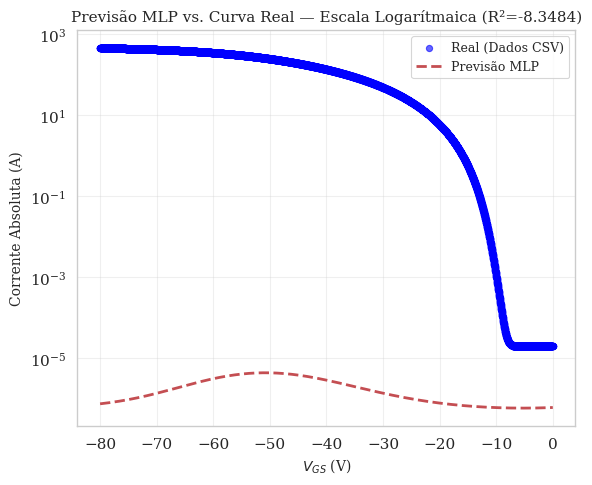

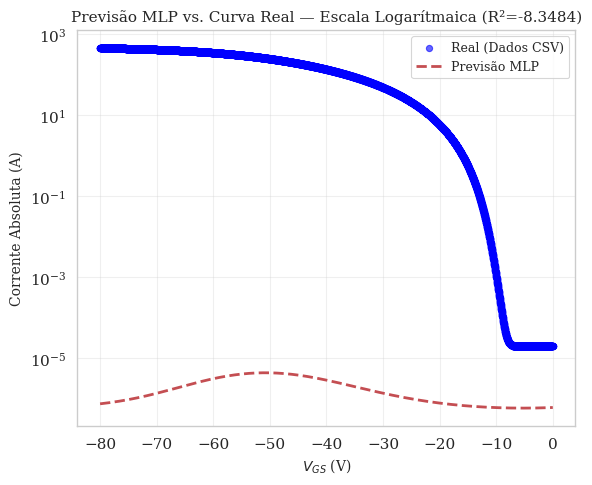

In [26]:
plot_curve_comparison2(
    V_data=V_real,
    I_real=I_real,
    V_fixed=v_fixed,
    is_transfer=is_transfer,
    mlp_model=(prepare_mlp_features, trained_model, feature_scaler, target_scaler),
    yscale="log",
    title="Previsão MLP vs. Curva Real — Escala Logarítmaica"
)

In [20]:
best_trial_number = study.best_trial.number
best_model_path   = f'models/optuna_trials/mlp_model_{TECNOLOGY}_trial_{best_trial_number}.pkl'

trained_model_best, feature_scaler_best, target_scaler_best = mlp_trainer.load_model(
    filename=best_model_path
)

print(f"Melhor modelo carregado: trial {best_trial_number}")
print(f"Caminho: {best_model_path}")

# Comparação visual com a curva real
plot_curve_comparison2(
    V_data=V_real,
    I_real=I_real,
    V_fixed=v_fixed,
    is_transfer=is_transfer,
    mlp_model=(prepare_mlp_features, trained_model_best, feature_scaler_best, target_scaler_best),
    yscale="log",
    title=f"Melhor Modelo Optuna (trial {best_trial_number}) vs. Curva Real"
)

NameError: name 'study' is not defined